[0.979, 1.033, 1.009, 1.025, 0.998, 0.99, 0.993, 1.02, 1.082, 1.085, 0.993, 1.026, 1.094, 0.987, 1.061, 1.021, 1.019, 0.992, 1.016, 1.014, 1.017, 1.016, 1.059, 1.021, 1.017, 1.073, 1.008, 1.003, 1.029, 1.007, 1.006, 1.013, 1.018, 1.052, 0.954, 1.024, 1.109, 1.04, 0.987, 1.036]


(array([ 1.,  1.,  7.,  7., 13.,  3.,  3.,  1.,  2.,  2.]),
 array([0.954 , 0.9695, 0.985 , 1.0005, 1.016 , 1.0315, 1.047 , 1.0625,
        1.078 , 1.0935, 1.109 ]),
 <BarContainer object of 10 artists>)

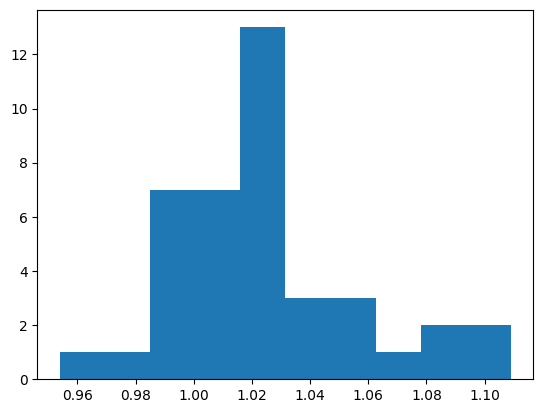

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "postgres"
postfix = "_02_index.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 1.0231499999999998
Стандартное отклонение: 0.03281224755702648
Отношение std/mean (%): 3.2069830970069386


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 0.010493865866930536


### Округление
- Погрешность: 0.010 (мс)
- Среднее: 1.023 (мс)
### Итог
- Результирующее значение: 1.023 ± 0.010 (мс)